In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [10]:
FEATURE_DIR = Path("../data/processed/features")

print("Feature directory:", FEATURE_DIR)
print("Exists:", FEATURE_DIR.exists())

Feature directory: ..\data\processed\features
Exists: True


In [11]:
pjme_path = FEATURE_DIR / "PJME_features.csv"

df = pd.read_csv(pjme_path)

print("PJME dataset loaded successfully")
print("Shape:", df.shape)

PJME dataset loaded successfully
Shape: (145198, 18)


In [12]:
df.head()

,Datetime,PJME_MW,hour,day,day_of_week,month,year,is_weekend,season,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168
0,2002-01-08 01:00:00,29445.0,1,8,1,1,2002,0,Winter,31187.0,33579.0,35997.0,26862.0,27100.0,30393.0,33452.583333,4559.767709,32519.511905
1,2002-01-08 02:00:00,28670.0,2,8,1,1,2002,0,Winter,29445.0,31187.0,33579.0,25976.0,26097.0,29265.0,33560.208333,4425.965952,32513.869048
2,2002-01-08 03:00:00,28375.0,3,8,1,1,2002,0,Winter,28670.0,29445.0,31187.0,25641.0,25793.0,28357.0,33672.458333,4256.159403,32510.327381
3,2002-01-08 04:00:00,28542.0,4,8,1,1,2002,0,Winter,28375.0,28670.0,29445.0,25666.0,25657.0,27899.0,33786.375000,4064.104959,32510.434524
4,2002-01-08 05:00:00,29261.0,5,8,1,1,2002,0,Winter,28542.0,28375.0,28670.0,26328.0,25778.0,28057.0,33906.208333,3851.076461,32514.261905


In [13]:
print(df.columns.tolist())

['Datetime', 'PJME_MW', 'hour', 'day', 'day_of_week', 'month', 'year', 'is_weekend', 'season', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168']


In [14]:
print(df.dtypes)

Datetime                str
PJME_MW             float64
hour                  int64
day                   int64
day_of_week           int64
month                 int64
year                  int64
is_weekend            int64
season                  str
lag_1               float64
lag_2               float64
lag_3               float64
lag_24              float64
lag_48              float64
lag_168             float64
rolling_mean_24     float64
rolling_std_24      float64
rolling_mean_168    float64
dtype: object


In [15]:
df["target"] = df["PJME_MW"].shift(-1)

In [16]:
df[["Datetime", "PJME_MW", "target"]].head(10)

,Datetime,PJME_MW,target
0,2002-01-08 01:00:00,29445.0,28670.0
1,2002-01-08 02:00:00,28670.0,28375.0
2,2002-01-08 03:00:00,28375.0,28542.0
3,2002-01-08 04:00:00,28542.0,29261.0
4,2002-01-08 05:00:00,29261.0,31348.0
5,2002-01-08 06:00:00,31348.0,35335.0
6,2002-01-08 07:00:00,35335.0,37841.0
7,2002-01-08 08:00:00,37841.0,37417.0
8,2002-01-08 09:00:00,37417.0,36824.0
9,2002-01-08 10:00:00,36824.0,36504.0


In [17]:
df[["Datetime", "PJME_MW", "target"]].tail()

,Datetime,PJME_MW,target
145193,2018-08-02 20:00:00,44057.0,43256.0
145194,2018-08-02 21:00:00,43256.0,41552.0
145195,2018-08-02 22:00:00,41552.0,38500.0
145196,2018-08-02 23:00:00,38500.0,35486.0
145197,2018-08-03 00:00:00,35486.0,NaN


In [18]:
df = df.dropna(subset=["target"]).copy()

In [19]:
print("Shape after removing missing target:", df.shape)
print("Missing targets:", df["target"].isna().sum())

Shape after removing missing target: (145197, 19)
Missing targets: 0


In [20]:
features = [
    "PJME_MW",
    "hour",
    "day",
    "day_of_week",
    "month",
    "year",
    "is_weekend",
    "season",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168"
]

target = "target"

In [21]:
print("Number of features:", len(features))
print("Features:", features)
print("Target:", target)

Number of features: 17
Features: ['PJME_MW', 'hour', 'day', 'day_of_week', 'month', 'year', 'is_weekend', 'season', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_168']
Target: target


In [22]:
X = df[features]
y = df[target]

In [23]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (145197, 17)
y shape: (145197,)


In [24]:
print(X.head())
print(y.head())

   PJME_MW  hour  day  day_of_week  month  year  is_weekend  season    lag_1  \
0  29445.0     1    8            1      1  2002           0  Winter  31187.0   
1  28670.0     2    8            1      1  2002           0  Winter  29445.0   
2  28375.0     3    8            1      1  2002           0  Winter  28670.0   
3  28542.0     4    8            1      1  2002           0  Winter  28375.0   
4  29261.0     5    8            1      1  2002           0  Winter  28542.0   

     lag_2    lag_3   lag_24   lag_48  lag_168  rolling_mean_24  \
0  33579.0  35997.0  26862.0  27100.0  30393.0     33452.583333   
1  31187.0  33579.0  25976.0  26097.0  29265.0     33560.208333   
2  29445.0  31187.0  25641.0  25793.0  28357.0     33672.458333   
3  28670.0  29445.0  25666.0  25657.0  27899.0     33786.375000   
4  28375.0  28670.0  26328.0  25778.0  28057.0     33906.208333   

   rolling_std_24  rolling_mean_168  
0     4559.767709      32519.511905  
1     4425.965952      32513.869048  
2 

In [25]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

print("Total rows:", n)
print("Training rows:", train_end)
print("Validation rows:", val_end - train_end)
print("Test rows:", n - val_end)

Total rows: 145197
Training rows: 101637
Validation rows: 21780
Test rows: 21780


In [26]:
X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val   = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

In [27]:
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (101637, 17)
X_val:   (21780, 17)
X_test:  (21780, 17)
y_train: (101637,)
y_val:   (21780,)
y_test:  (21780,)


In [28]:
print("Training period:")
print(df["Datetime"].iloc[0])
print("to")
print(df["Datetime"].iloc[train_end - 1])

print("\nValidation period:")
print(df["Datetime"].iloc[train_end])
print("to")
print(df["Datetime"].iloc[val_end - 1])

print("\nTest period:")
print(df["Datetime"].iloc[val_end])
print("to")
print(df["Datetime"].iloc[-1])

Training period:
2002-01-08 01:00:00
to
2013-08-13 21:00:00

Validation period:
2013-08-13 22:00:00
to
2016-02-07 10:00:00

Test period:
2016-02-07 11:00:00
to
2018-08-02 23:00:00


In [29]:
baseline_pred = X_test["PJME_MW"]

In [30]:
baseline_error = y_test - baseline_pred

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE :", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²  :", baseline_r2)

Baseline MAE : 1054.7565197428835
Baseline RMSE: 1354.6016157939125
Baseline R²  : 0.9557974355356257


In [32]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.0


In [33]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [34]:
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

print("XGBoost training completed.")

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:season: str

In [35]:
features = [
    "PJME_MW",
    "hour",
    "day",
    "day_of_week",
    "month",
    "year",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168"
]

In [36]:
X = df[features]
y = df[target]

In [37]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
X_test = X.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

In [38]:
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (101637, 16)
X_val:   (21780, 16)
X_test:  (21780, 16)
y_train: (101637,)
y_val:   (21780,)
y_test:  (21780,)


In [39]:
print(X_train.dtypes)

PJME_MW             float64
hour                  int64
day                   int64
day_of_week           int64
month                 int64
year                  int64
is_weekend            int64
lag_1               float64
lag_2               float64
lag_3               float64
lag_24              float64
lag_48              float64
lag_168             float64
rolling_mean_24     float64
rolling_std_24      float64
rolling_mean_168    float64
dtype: object


In [40]:
print("Non-numeric columns:")
print(X_train.select_dtypes(exclude="number").columns.tolist())

Non-numeric columns:
[]


In [41]:
xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

print("XGBoost training completed.")

XGBoost training completed.


In [42]:
xgb_val_pred = xgb_model.predict(X_val)

print("Validation predictions created.")
print("Number of predictions:", len(xgb_val_pred))

Validation predictions created.
Number of predictions: 21780


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_val_mae = mean_absolute_error(y_val, xgb_val_pred)
xgb_val_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
xgb_val_r2 = r2_score(y_val, xgb_val_pred)

print("XGBoost Validation MAE :", xgb_val_mae)
print("XGBoost Validation RMSE:", xgb_val_rmse)
print("XGBoost Validation R²  :", xgb_val_r2)

XGBoost Validation MAE : 220.2263149068813
XGBoost Validation RMSE: 307.0335378068952
XGBoost Validation R²  : 0.9975340345176307


In [44]:
xgb_test_pred = xgb_model.predict(X_test)

print("Test predictions created.")
print("Number of predictions:", len(xgb_test_pred))

Test predictions created.
Number of predictions: 21780


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_test_mae = mean_absolute_error(y_test, xgb_test_pred)
xgb_test_rmse = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
xgb_test_r2 = r2_score(y_test, xgb_test_pred)

print("XGBoost Test MAE :", xgb_test_mae)
print("XGBoost Test RMSE:", xgb_test_rmse)
print("XGBoost Test R²  :", xgb_test_r2)

XGBoost Test MAE : 251.53799240630738
XGBoost Test RMSE: 346.83196080390206
XGBoost Test R²  : 0.9971022393546572


In [46]:
test_results = pd.DataFrame({
    "Datetime": df.iloc[val_end:]["Datetime"].values,
    "Actual": y_test.values,
    "Predicted": xgb_test_pred
})

test_results["Residual"] = (
    test_results["Actual"] - test_results["Predicted"]
)

test_results["Absolute_Error"] = (
    test_results["Residual"].abs()
)

test_results.head()

,Datetime,Actual,Predicted,Residual,Absolute_Error
0,2016-02-07 11:00:00,30504.0,30380.509766,123.490234,123.490234
1,2016-02-07 12:00:00,30092.0,29923.658203,168.341797,168.341797
2,2016-02-07 13:00:00,29762.0,29610.707031,151.292969,151.292969
3,2016-02-07 14:00:00,29602.0,29301.294922,300.705078,300.705078
4,2016-02-07 15:00:00,29898.0,29600.496094,297.503906,297.503906


In [53]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,PJME_MW,0.682959
7,lag_1,0.222199
1,hour,0.034005
8,lag_2,0.015922
13,rolling_mean_24,0.010796
9,lag_3,0.007887
3,day_of_week,0.007160
10,lag_24,0.006042
6,is_weekend,0.005840
14,rolling_std_24,0.002375


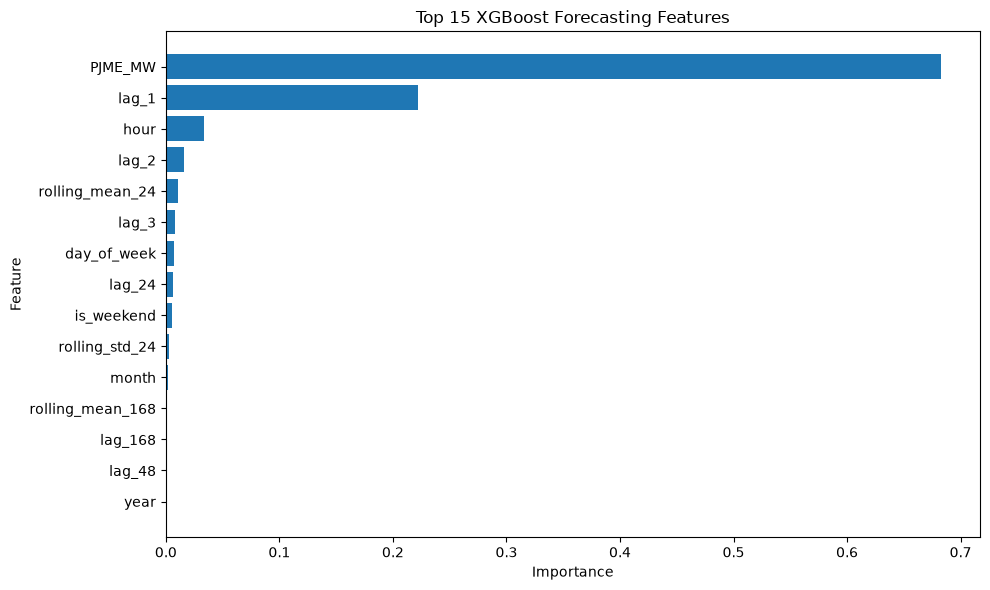

In [48]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Forecasting Features")

plt.tight_layout()
plt.show()

In [49]:
import os
import joblib

os.makedirs("../models", exist_ok=True)

model_path = "../models/xgboost_forecasting_model.pkl"

joblib.dump(xgb_model, model_path)

print("Model saved successfully.")
print("Path:", model_path)

Model saved successfully.
Path: ../models/xgboost_forecasting_model.pkl


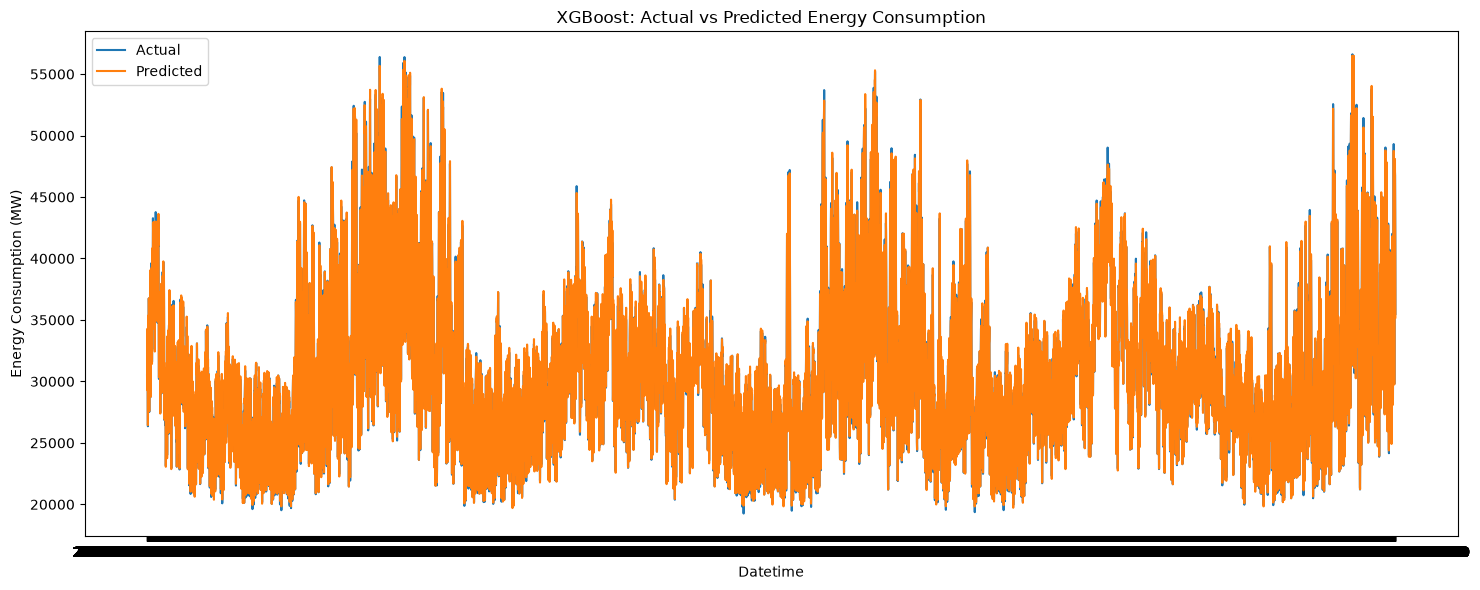

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    test_results["Datetime"],
    test_results["Actual"],
    label="Actual"
)

plt.plot(
    test_results["Datetime"],
    test_results["Predicted"],
    label="Predicted"
)

plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")
plt.title("XGBoost: Actual vs Predicted Energy Consumption")

plt.legend()
plt.tight_layout()
plt.show()

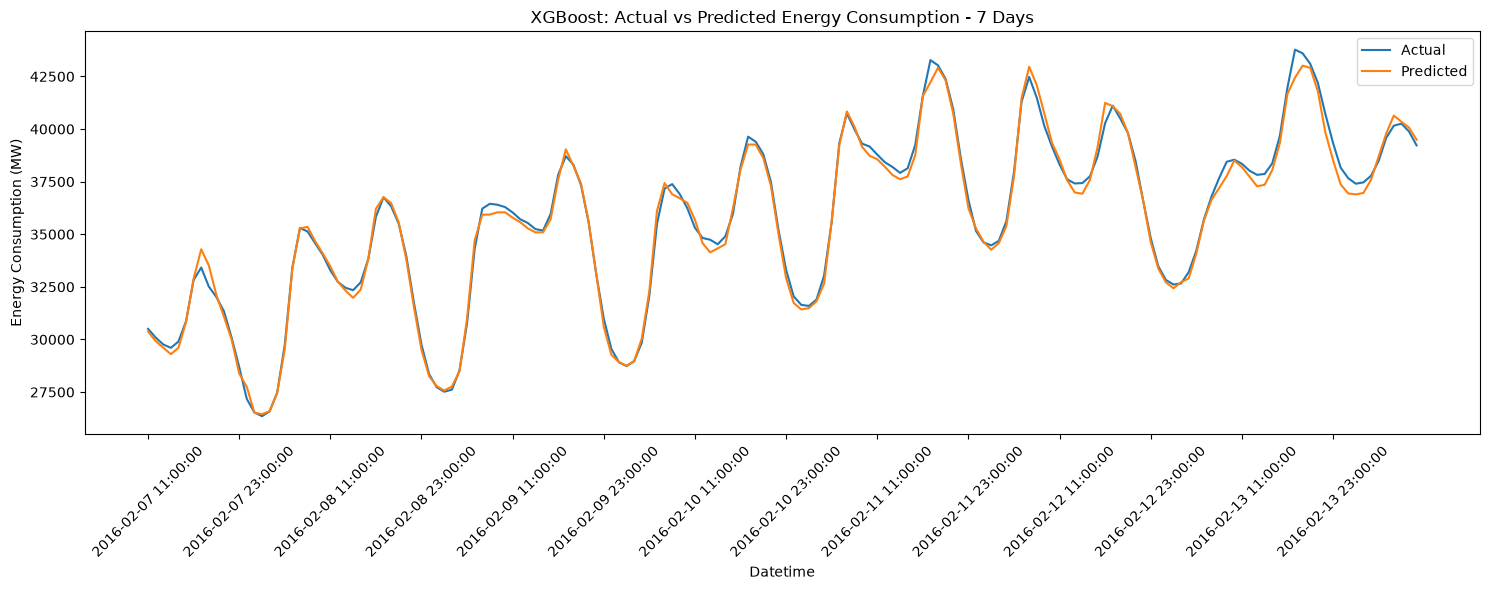

In [51]:
# Show first 7 days
plot_data = test_results.head(24 * 7)

plt.figure(figsize=(15, 6))

plt.plot(
    plot_data["Datetime"],
    plot_data["Actual"],
    label="Actual"
)

plt.plot(
    plot_data["Datetime"],
    plot_data["Predicted"],
    label="Predicted"
)

plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")
plt.title("XGBoost: Actual vs Predicted Energy Consumption - 7 Days")

plt.legend()

# Show only every 12 hours on x-axis
plt.xticks(
    plot_data["Datetime"][::12],
    rotation=45
)

plt.tight_layout()
plt.show()

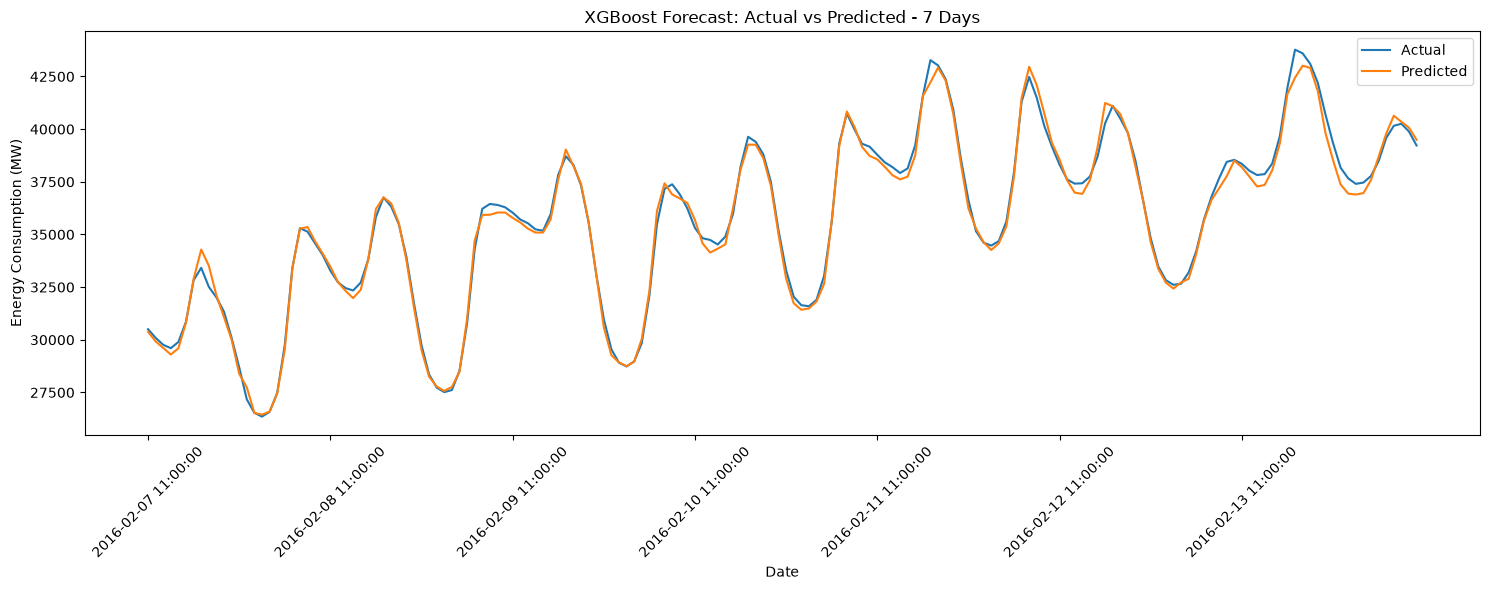

In [52]:
plt.figure(figsize=(15, 6))

plt.plot(
    plot_data["Datetime"],
    plot_data["Actual"],
    label="Actual"
)

plt.plot(
    plot_data["Datetime"],
    plot_data["Predicted"],
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Energy Consumption (MW)")
plt.title("XGBoost Forecast: Actual vs Predicted - 7 Days")

plt.legend()

plt.xticks(
    plot_data["Datetime"][::24],
    rotation=45
)

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load PJME features
pjme_df = pd.read_csv("../data/processed/features/PJME_features.csv")
pjme_df["Datetime"] = pd.to_datetime(pjme_df["Datetime"])
pjme_df = pjme_df.sort_values("Datetime").reset_index(drop=True)

print("PJME features loaded:", pjme_df.shape)


PJME features loaded: (145198, 18)


In [2]:
feature_cols = [
    "PJME_MW", "hour", "day", "day_of_week", "month", "year",
    "is_weekend", "lag_1", "lag_2", "lag_3", "lag_24", "lag_48",
    "lag_168", "rolling_mean_24", "rolling_std_24", "rolling_mean_168"
]

# Create next-hour target
pjme_df["target"] = pjme_df["PJME_MW"].shift(-1)

# Drop NaN rows
pjme_df = pjme_df.dropna(subset=feature_cols + ["target"]).reset_index(drop=True)

X_pjme = pjme_df[feature_cols]
y_pjme = pjme_df["target"]

# Same 70/15/15 split
n = len(X_pjme)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_test = X_pjme.iloc[val_end:]
y_test = y_pjme.iloc[val_end:]

print("Total rows  :", n)
print("Test rows   :", len(X_test))


Total rows  : 145197
Test rows   : 21780


In [3]:
# Load the PJME model
model_pjme = joblib.load("../models/xgboost_forecasting_model.pkl")

# Predict on test set
test_pred_pjme = model_pjme.predict(X_test)

# Metrics
mae  = mean_absolute_error(y_test, test_pred_pjme)
rmse = np.sqrt(mean_squared_error(y_test, test_pred_pjme))
r2   = r2_score(y_test, test_pred_pjme)

print(f"PJME Test MAE  : {mae:.3f}")
print(f"PJME Test RMSE : {rmse:.3f}")
print(f"PJME Test R2   : {r2:.6f}")


PJME Test MAE  : 251.538
PJME Test RMSE : 346.832
PJME Test R2   : 0.997102


In [4]:
# Create clean prediction DataFrame
pjme_predictions = pd.DataFrame({
    "Datetime":  pjme_df["Datetime"].iloc[val_end:].values,
    "Actual":    y_test.values,
    "Predicted": test_pred_pjme
})

print(pjme_predictions.head(10))
print("Shape:", pjme_predictions.shape)


             Datetime   Actual     Predicted
0 2016-02-07 11:00:00  30504.0  30380.509766
1 2016-02-07 12:00:00  30092.0  29923.658203
2 2016-02-07 13:00:00  29762.0  29610.707031
3 2016-02-07 14:00:00  29602.0  29301.294922
4 2016-02-07 15:00:00  29898.0  29600.496094
5 2016-02-07 16:00:00  30863.0  30824.023438
6 2016-02-07 17:00:00  32827.0  32888.804688
7 2016-02-07 18:00:00  33418.0  34285.292969
8 2016-02-07 19:00:00  32514.0  33518.113281
9 2016-02-07 20:00:00  32014.0  32111.687500
Shape: (21780, 3)


In [5]:
# Save to correct predictions folder
output_path = "../data/processed/predictions/PJME_predictions.csv"

pjme_predictions.to_csv(output_path, index=False)

print("Saved successfully!")
print("Path:", os.path.abspath(output_path))
print("Rows:", len(pjme_predictions))
print("Columns:", pjme_predictions.columns.tolist())


Saved successfully!
Path: c:\Users\sukhy\Desktop\smart-energy-project\data\processed\predictions\PJME_predictions.csv
Rows: 21780
Columns: ['Datetime', 'Actual', 'Predicted']
